In [1]:
import imutils
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import torch
from IPython.display import Image

In [3]:
!python ../yolov5/train.py --batch 16 --epochs 30 --data ./datasets/amir_dataset/data.yaml --weights ../yolov5/yolov5m.pt --cache

train: weights=../yolov5/yolov5m.pt, cfg=, data=./datasets/amir_dataset/data.yaml, hyp=..\yolov5\data\hyps\hyp.scratch-low.yaml, epochs=30, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=..\yolov5\data\hyps, resume_evolve=None, bucket=, cache=ram, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=..\yolov5\runs\train, name=exp, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, artifact_alias=latest, ndjson_console=False, ndjson_file=False
github: up to date with https://github.com/ultralytics/yolov5 
YOLOv5  v7.0-399-g125d4559 Python-3.12.9 torch-2.6.0+cpu CPU

hyperparameters: lr0=0.01, lrf=0.01, momentum=0.937, weight_decay=0.0005, warmup_epochs=3.0, warmup_momentum=0.8, warmup_bias_lr=0.1, box

In [2]:
%load_ext tensorboard
%tensorboard --logdir ../yolov5/runs/train/exp11

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Amir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\Scripts\tensorboard.exe\__main__.py", line 7, in <module>
  File "C:\Users\Amir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tensorboard\main.py", line 41, in run_main
    app.run(tensorboard.main, flags_parser=tensorboard.configure)
  File "C:\Users\Amir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\absl\app.py", line 308, in run
    _run_main(main, args)
  File "C:\Users\Amir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-pa

In [3]:
import cv2

def capture_photo():
    cap = cv2.VideoCapture(0)  # Open webcam

    if not cap.isOpened():
        print("Error: Could not open webcam.")
        return

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, (440, 680))
        # Show live webcam feed
        cv2.imshow("Press 'c' to Capture", frame)

        # Wait for key press
        key = cv2.waitKey(1) & 0xFF
        if key == ord('c'):  # Press 'c' to capture
            cv2.imwrite("./images/captured_image.jpg", frame)
            print("Image saved as 'captured_image.jpg'")
            break
        elif key == 27:  # Press 'ESC' to exit
            break

    cap.release()
    cv2.destroyAllWindows()

In [17]:
capture_photo()

Image saved as 'captured_image.jpg'


In [ ]:
!python ../yolov5/detect.py --source ./images/captured_image.jpg --weights ../yolov5/runs/train/exp11/weights/best.pt

## From webcam

In [4]:
!python ../yolov5/detect.py --source 0 --weights ../yolov5/runs/train/exqp11/weights/best.pt

detect: weights=['../yolov5/runs/train/exp11/weights/best.pt'], source=0, data=..\yolov5\data\coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=..\yolov5\runs\detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5  v7.0-399-g125d4559 Python-3.12.9 torch-2.6.0+cpu CPU

Fusing layers... 
Model summary: 212 layers, 20861016 parameters, 0 gradients, 47.9 GFLOPs
1/1: 0...  Success (inf frames 720x1280 at 30.00 FPS)

0: 640x384 1 Head, 161.4ms
0: 640x384 1 Head, 1 One, 1 Two, 142.2ms
0: 640x384 1 Head, 1 One, 1 Two, 137.2ms
0: 640x384 1 Head, 1 One, 1 Two, 137.8ms
0: 640x384 1 Head, 129.1ms
0: 640x384 1 Head, 1 One, 126.6ms
0: 640x384 1 Head, 126.4ms
0: 640x384 1 Head, 1 Two, 124.1ms


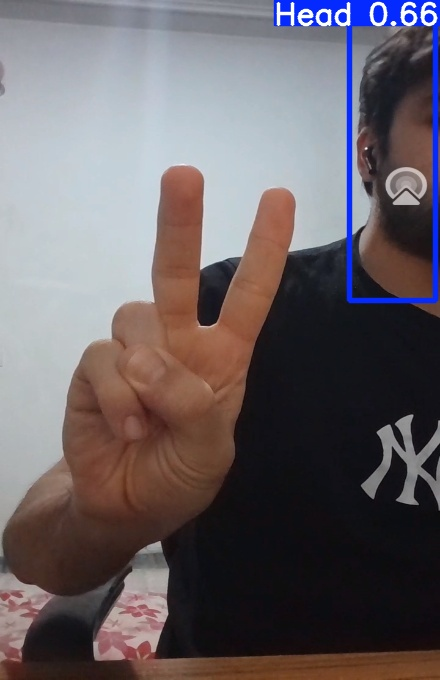

In [21]:
Image("../yolov5/runs/detect/exp13/captured_image.jpg")